<a href="https://colab.research.google.com/github/T1toh/30Days_of_SQL/blob/main/MODULE_2_%7C_LESSON_4_Credit_Market_Instruments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAPSTONE REVIEW**
## MODULE 2 | LESSON 4: Credit Market Instruments
---

| | |
|:---|:---|
|**Reading Time** | 4h |
|**Prior Knowledge** | fixed income fundamentals, derivatives pricing, probability theory, statistical modeling, portfolio theory |
|**Keywords** | corporate bonds, credit default swaps, credit spreads, default probability, recovery rates, CDS basis, credit indices, total return swaps, OTC markets, capital structure arbitrage, maximum likelihood estimation |

---

## **Introduction**


Credit markets represent the universe of securities where one party lends money to another, creating a relationship fraught with the possibility of default. Unlike equity markets where ownership stakes are traded, credit markets trade in obligations – IOUs that carry the fundamental risk that the borrower might not pay back.

This distinction matters more than you might think. Credit markets dwarf equity markets in size, with over $24 trillion in bond issuance alone in 2020. Why such massive scale? Because credit is the lifeblood of modern economies (can you imagine corporate expansion without debt financing?).

It pays to look at this ecosystem carefully. We're not just dealing with simple bonds anymore – the modern credit market has evolved into a sophisticated apparatus for slicing, dicing, and trading credit risk itself.

## **1. Credit Market Products**

### **1.1 Corporate Bonds**

Corporate bonds are IOUs with attitude. Unlike their boring government cousins, corporate bonds must compensate investors for the uncomfortable possibility that the company might go bankrupt. This compensation comes in the form of credit spreads – the extra yield you demand for taking on default risk.

Think of credit spreads as fear premiums. The more frightened investors are about a company's future, the higher the spread. This isn't just market psychology – it's mathematical reality. The spread reflects the market's collective assessment of default probability, recovery expectations, and risk aversion.

But here's where it gets interesting: investment-grade bonds (rated BBB- and above) often behave differently from high-yield "junk" bonds (below BBB-). The relationship isn't linear – credit spreads can explode during times of stress, particularly for lower-rated issuers. Why? Because credit risk isn't normally distributed, and tail events can create massive spread widening.

### **1.2 Credit Default Swaps (CDS)**

Credit default swaps are the most elegant financial innovation you've probably never heard of – they turn credit risk into a tradeable commodity. Imagine being able to buy insurance on someone else's house fire. That's essentially what CDS accomplishes for credit risk.

The beauty lies in the separation of risk from ownership. You can buy CDS protection on IBM bonds without owning a single IBM bond. This creates pure credit exposure – no interest rate risk, no liquidity issues, just naked credit risk. It's like financial strip-mining, extracting one specific risk component from a complex security.

Standard CDS contracts cover five years with quarterly payments. The premium, quoted in basis points, provides a liquid measure of default risk. Often more liquid than the underlying bonds themselves (why might that be?). This liquidity premium has transformed how institutions manage credit exposure.

### **1.3 Loan Credit Default Swaps (LCDS)**

LCDS extends the CDS concept to loans – and this matters because loans aren't just junior bonds. They typically rank higher in the capital structure, often with different recovery characteristics. Banks holding large loan portfolios can now hedge specific credit exposures without the operational complexity of selling loans.

The development of LCDS markets has been particularly important for institutional investors seeking loan exposure. Given that loans trade infrequently, LCDS provides price discovery and risk management tools that would otherwise be unavailable.

### **1.4 Credit Indices**

Credit indices aggregate individual CDS spreads into tradeable benchmarks – think of them as the S&P 500 of credit markets. The CDX indices in North America and iTraxx indices in Europe typically include 125 entities, reconstituted every six months to maintain market relevance.

These indices serve multiple masters: benchmarking, hedging, and structured product creation. Want to bet on European credit quality deteriorating? Buy protection on the iTraxx Europe index. The standardization has dramatically improved market liquidity, but it's also created new forms of systemic risk (can you see why?).

### **1.5 Total Return Swaps (TRS)**

Total return swaps let you own bonds without owning them. The total return payer agrees to pay everything – coupons, capital appreciation, the works – while receiving a funding rate. It's leveraged credit exposure without the balance sheet impact.

This structure appeals to leveraged investors and those facing regulatory constraints on direct ownership. But it also creates counterparty risk – if your TRS counterparty fails, you're exposed to both credit and counterparty risk simultaneously.

## **2. Trading Mechanics**

### **2.1 OTC Markets and Dealer Networks**

Credit markets remain stubbornly over-the-counter. Why? Because credit instruments are heterogeneous beasts – even bonds from the same issuer can have vastly different terms, making exchange trading challenging.

Dealer networks provide the plumbing for this market. Primary dealers maintain inventories and provide two-way markets, earning bid-ask spreads while bearing inventory risk. But here's the catch: post-2008 regulations have shrunk dealer balance sheets, potentially reducing liquidity when you need it most.

This creates a paradox – markets have grown larger while dealer capacity has shrunk. The result? Electronic platforms are gaining market share, but human dealers remain essential for complex transactions and stressed market conditions.

### **2.2 Electronic Platforms**

Electronic trading has revolutionized credit markets, particularly for liquid investment-grade bonds. Platforms like MarketAxess facilitate price discovery and execution, providing transparency that was unimaginable a decade ago.

The protocols vary: request-for-quote systems where dealers compete, all-to-all platforms where institutions trade directly, and auction mechanisms for large blocks. Each serves different purposes, but all represent the gradual institutionalization of previously relationship-driven markets.

### **2.3 Market Conventions and Documentation**

ISDA documentation provides the legal framework for credit derivatives. The Master Agreement, combined with standardized confirmations, establishes terms and reduces operational risk. But the devil lives in the details – credit event definitions, settlement procedures, and auction mechanisms can make or break a trade.

Consider the complexity: What exactly constitutes "bankruptcy"? How is recovery determined? The ISDA Credit Derivatives Definitions run to hundreds of pages, reflecting the complexity of modern credit markets.

## **3. Pricing Methodologies**

### **3.1 Credit Spread Analysis**

Credit spreads are like onions – they have layers. The spread decomposes into expected loss, risk premium, liquidity premium, and technical factors. Understanding these components is crucial for relative value analysis.

Expected loss is the mathematical expectation of default losses. But market spreads typically exceed expected losses because investors are risk-averse. They demand compensation for uncertainty, not just expected outcomes. This risk premium varies with market conditions and can disappear entirely during periods of extreme stress.

The term structure of credit spreads typically slopes upward – longer maturities carry higher spreads due to cumulative default risk. But this relationship can invert during crisis periods when near-term survival becomes the primary concern.

Credit spreads are fear premiums made visible – they represent the extra compensation investors demand for bearing the uncomfortable possibility that corporate borrowers might default. In this example, we'll examine how investment-grade credit spreads (the difference between corporate bond yields and risk-free Treasury yields) behave over economic cycles. Using real market data spanning over three decades, we'll demonstrate the dynamic relationship between credit risk assessment and macroeconomic conditions. The analysis reveals how spreads widen dramatically during periods of economic stress, reflecting both increased default probabilities and heightened risk aversion. We'll also explore the correlation between credit spreads and market volatility (VIX), illustrating how different risk measures move together during periods of financial turbulence.

In [2]:
pip install fredapi

/usr/local/lib/python3.13/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


Google Sheet: SPY&VIX_data
Exact sheet/tab: Sheet1
Columns: ['BAA', 'UST10', 'REC', 'SPY', 'VIX', 'Spread_bp', 'Ret_SPY']
Data range: 1993-02-01 to 2026-09-25

             BAA  UST10  REC        SPY    VIX  Spread_bp   Ret_SPY
1993-02-01  8.39   6.38  0.0  24.553852  12.33      201.0  0.007088
1993-02-02  8.39   6.46  0.0  24.605865  12.25      193.0  0.002116
1993-02-03  8.39   6.45  0.0  24.865980  12.12      194.0  0.010516
1993-02-04  8.39   6.39  0.0  24.970011  12.29      200.0  0.004175
1993-02-05  8.39   6.32  0.0  24.952679  12.90      207.0 -0.000694

             BAA  UST10  REC         SPY    VIX  Spread_bp  Ret_SPY
2026-09-21  6.32   4.96  0.0  600.150024  19.83      136.0      0.0
2026-09-22  6.32   4.96  0.0  600.150024  19.83      136.0      0.0
2026-09-23  6.32   5.11  0.0  600.150024  19.83      121.0      0.0
2026-09-24  6.32   5.18  0.0  600.150024  19.83      114.0      0.0
2026-09-25  6.32   5.17  0.0  600.150024  19.83      115.0      0.0


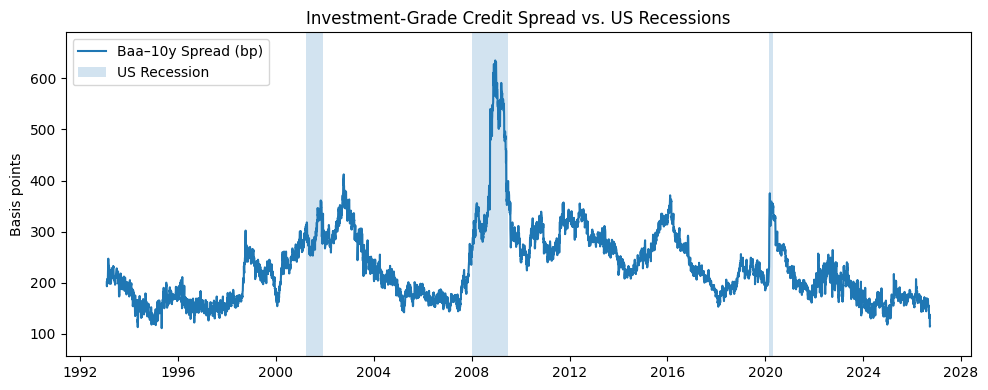

In [4]:
import pandas as pd
from datetime import datetime
from fredapi import Fred
import matplotlib.pyplot as plt
import numpy as np
from google.colab import auth
import gspread
from google.auth import default

auth.authenticate_user()

creds, _ = default()
gc = gspread.authorize(creds)

spreadsheet = gc.open_by_key("1gR15pMtlNazD2RMDz84bWMRxN0NFOP_HuQrsbFetuys")

worksheet = spreadsheet.worksheet("Sheet1")

data = worksheet.get_all_values()

yfin = pd.DataFrame(data[1:], columns=data[0])

yfin.columns = yfin.columns.str.strip()

yfin.iloc[:, 0] = pd.to_datetime(yfin.iloc[:, 0], errors="coerce")

for col in yfin.columns[1:]:
    yfin[col] = (
        yfin[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "None": np.nan, "nan": np.nan})
    )
    yfin[col] = pd.to_numeric(yfin[col], errors="coerce")

yfin = yfin.set_index(yfin.columns[0])

if "SPY" not in yfin.columns or "VIX" not in yfin.columns:
    raise ValueError(
        f"Expected SPY and VIX columns, but found: {list(yfin.columns)}"
    )

fred = Fred(api_key="84862c20ea45f3e79664a45656378e7f")

start = "1990-01-01"
end = datetime.today().strftime("%Y-%m-%d")

series_ids = {
    "BAA": "BAA",
    "UST10": "DGS10",
    "REC": "USREC"
}

fred_df = pd.concat(
    {
        name: fred.get_series(
            sid,
            observation_start=start,
            observation_end=end
        )
        for name, sid in series_ids.items()
    },
    axis=1
)

fred_df.index = pd.to_datetime(fred_df.index)

raw = pd.concat(
    [fred_df, yfin],
    axis=1
).sort_index()

raw[["BAA", "UST10", "REC", "SPY", "VIX"]] = (
    raw[["BAA", "UST10", "REC", "SPY", "VIX"]]
    .apply(pd.to_numeric, errors="coerce")
)

raw = raw.ffill()

raw["Spread_bp"] = (raw["BAA"] - raw["UST10"]) * 100

raw["Ret_SPY"] = np.log(
    raw["SPY"] / raw["SPY"].shift(1)
)

raw = raw.replace([np.inf, -np.inf], np.nan)

raw = raw.dropna(
    subset=[
        "BAA",
        "UST10",
        "REC",
        "SPY",
        "VIX",
        "Spread_bp",
        "Ret_SPY"
    ]
)

print("Google Sheet:", spreadsheet.title)
print("Exact sheet/tab:", worksheet.title)
print("Columns:", list(raw.columns))
print("Data range:", raw.index.min().date(), "to", raw.index.max().date())
print()
print(raw.head())
print()
print(raw.tail())

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    raw.index,
    raw["Spread_bp"],
    label="Baa–10y Spread (bp)"
)

ax.set_ylabel("Basis points")
ax.set_title("Investment-Grade Credit Spread vs. US Recessions")

ax.fill_between(
    raw.index,
    0,
    1,
    where=raw["REC"].astype(bool),
    transform=ax.get_xaxis_transform(),
    alpha=0.2,
    label="US Recession"
)

ax.legend()

plt.tight_layout()
plt.show()

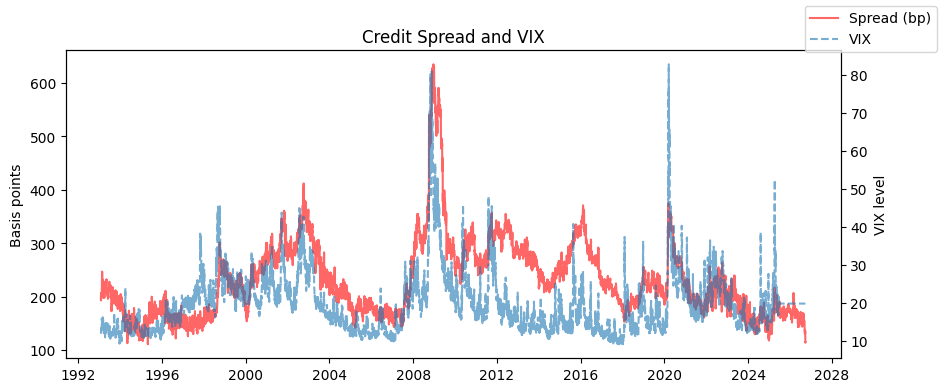

In [5]:
fig, ax1 = plt.subplots(figsize=(10,4))
ax2 = ax1.twinx()
ax1.plot(raw.index, raw["Spread_bp"], label="Spread (bp)", color = 'red', alpha = 0.6)
ax2.plot(raw.index, raw["VIX"], linestyle="--", label="VIX", alpha=.6)
ax1.set_ylabel("Basis points"); ax2.set_ylabel("VIX level")
ax1.set_title("Credit Spread and VIX")
fig.legend(loc="upper right")
plt.show()

Notice how credit spreads exhibit pronounced cyclical behavior, widening to over 600 basis points during the 2008 financial crisis and spiking again during the COVID-19 pandemic in early 2020. These aren't just statistical artifacts – they represent real money. A 400 basis point spread widening means corporate borrowers must pay an additional 4% annual interest compared to the Treasury rate, dramatically increasing funding costs precisely when companies are most vulnerable.

The relationship with VIX is particularly instructive. Both measures spike simultaneously during crisis periods, confirming that credit risk and equity market volatility are manifestations of the same underlying economic uncertainty. However, notice that credit spreads tend to be more persistent than VIX spikes – while equity market fear can dissipate quickly, credit markets remain skeptical longer, reflecting the asymmetric nature of credit risk (bonds can only pay back principal, never more).

The recession shading reveals another crucial insight: credit spreads often begin widening before official recession declarations, suggesting that credit markets serve as leading indicators of economic distress. This makes intuitive sense – corporate bond investors are essentially lending money with the expectation of being paid back, making them naturally forward-looking in their risk assessment. The gradual normalization following each crisis period reflects the slow restoration of confidence as economic fundamentals improve and default fears subside.

### **3.2 Default Probability Modeling**

Two philosophical approaches dominate default modeling: structural models that model the economic mechanism of default, and reduced-form models that treat default as a statistical process.

Structural models, like Merton's approach, are intuitive – default occurs when asset values fall below debt obligations. They link default probability to firm fundamentals and provide economic insight. But they struggle with short-term default prediction and complex capital structures.

Reduced-form models sidestep the economic mechanism, directly modeling default intensity. They're more flexible and can be calibrated to market prices, making them popular for derivatives pricing. The hazard rate becomes the key parameter (why might this be controversial?).

Modern approaches increasingly employ machine learning. Logistic regression, random forests, and neural networks can capture complex relationships that traditional models miss. But this creates new challenges – how do you explain a neural network's decision to a credit committee?

### **3.3 Recovery Rate Assumptions**

Recovery rates are the ugly stepchild of credit modeling – crucial but poorly understood. Historical data is limited and biased, making prediction difficult. Worse, recovery rates are negatively correlated with default rates, exactly when you need diversification most.

Industry and seniority matter enormously. Senior secured debt might recover 70% while subordinated debt recovers 30%. Airlines have terrible recovery rates (hard to repossess a used airplane), while utilities do better (power plants don't move).

The challenge is that recovery rates are highly scenario-dependent. What looks like a 60% recovery rate in normal times might become 20% during a systematic crisis.

### **3.4 CDS Basis Analysis**

The CDS basis – the difference between bond spreads and CDS spreads – should theoretically be near zero. Both instruments reflect the same underlying credit risk. But persistent basis exists due to funding costs, regulatory treatment, and supply-demand imbalances.

A positive basis (bond spread > CDS spread) might indicate cheap bonds or expensive CDS protection. But be careful – basis trades are not risk-free arbitrage. They remain exposed to changes in correlation, liquidity differences, and contract technicalities.

## **4. Trading Strategies**

### **4.1 Credit Curve Positioning**

Credit curves tell stories about market expectations. A steep curve suggests deteriorating long-term prospects, while a flat curve might indicate stable credit quality or technical factors.

Curve trades involve relative positions across maturities. Buy long-term protection and sell short-term protection to profit from steepening. But remember carry and roll-down effects – these positions have time decay that can work for or against you.

### **4.2 Capital Structure Arbitrage**

Capital structure arbitrage exploits inconsistencies within the same issuer's securities. All securities should reflect consistent default probabilities and recovery expectations (why might this assumption be wrong?).

Common trades include equity-CDS relative value, comparing implied default probabilities from equity volatility with CDS spreads. But modern capital structures are complex beasts – multiple debt layers, hybrid securities, and complex covenants can create legitimate pricing differences.

### **4.3 Basis Trades**

Basis trades attempt to profit from bond-CDS basis movements while minimizing directional credit exposure. Long basis trades profit from basis widening, short basis trades from tightening.

These trades are popular because they appear to isolate technical factors from fundamental credit risk. But basis risk is real – bonds and CDS can decouple during stress periods, creating losses even when credit quality remains stable.

### **4.4 Distressed Debt Strategies**

Distressed debt investing is vulture capitalism at its finest – purchasing securities of financially troubled companies at significant discounts. This requires specialized expertise in bankruptcy law, restructuring processes, and asset valuation.

Three approaches dominate: passive buy-and-hold, active event-driven trading, and control-oriented strategies. Each requires different skills and risk tolerances. The market often exhibits significant inefficiencies due to forced selling and limited specialized expertise.

## **5. Risk Management**

### **5.1 Default Risk**

Default risk is the fundamental risk in credit markets. Portfolio-level default risk involves concentration limits, correlation modeling, and tail risk assessment. Monte Carlo simulation provides powerful tools for modeling portfolio losses, but the models are only as good as their assumptions.

Expected loss provides a starting point, but risk management requires understanding the full loss distribution. Value at Risk and Expected Shortfall capture tail risks that expected loss measures miss entirely.

### **5.2 Downgrade Risk**

Rating changes can impact bond prices even without default. This is particularly important for investment-grade bonds, where downgrades can trigger forced selling by rating-constrained investors.

Migration matrices show rating transition probabilities, but these relationships are unstable. During economic downturns, downgrade activity increases and correlation between issuers rises, exactly when diversification is most needed.

### **5.3 Liquidity Risk**

Liquidity risk manifests as both funding risk (inability to fund positions) and market risk (inability to trade without price impact). The 2008 crisis demonstrated how quickly liquidity can evaporate, particularly for lower-rated credits.

Liquidity varies dramatically across market segments. Investment-grade bonds generally offer better liquidity than high-yield, while CDS markets may provide more consistent liquidity due to standardization. But don't count on liquidity during stress periods (why might this be a dangerous assumption?).

### **5.4 Correlation Risk**

Credit correlations are unstable and tend to increase during stress periods. This correlation breakdown can cause portfolio losses to exceed estimates based on historical relationships.

Understanding correlation drivers is crucial – industry factors, geographic exposure, and macroeconomic sensitivity all matter. Stress testing should incorporate elevated correlation scenarios to assess potential losses during crisis periods.

### **5.5 Model Risk**

Model risk is particularly acute in credit markets due to limited historical data for extreme events and the complexity of credit instruments. Default probability models may fail during structural changes, while recovery rate models rely on sparse historical data.

Model risk management requires validation, backtesting, and sensitivity analysis. Multiple models should be used when possible, and model limitations must be clearly understood. Remember: all models are wrong, but some are useful.

## **6. Computational Methods**

### **6.1 Maximum Likelihood Estimation for Credit Parameters**

Maximum likelihood estimation provides the foundation for credit parameter estimation. For simple default probability estimation with $n$ obligors and $k$ defaults, the likelihood function is:

$$L(p) = p^k(1-p)^{n-k}$$

The MLE is simply $\hat{p} = k/n$. But more complex models require sophisticated numerical optimization.

For hazard rate models with time-varying default intensities:

$$\lambda(t|X(t)) = \lambda_0(t)\exp(\beta'X(t))$$

The likelihood function involves both hazard rates and survival functions. Modern software provides robust implementations, but understanding the underlying assumptions remains crucial.

### **6.2 Monte Carlo Simulation for Portfolio Credit Risk**

Monte Carlo simulation provides flexible tools for portfolio credit risk modeling. The basic approach involves simulating correlated default events and calculating resulting loss distributions.

Key implementation steps:
1. Generate correlated random variables using Cholesky decomposition or copula functions
2. Transform to default indicators by comparing with default probabilities
3. Calculate portfolio losses for each simulation
4. Analyze the resulting loss distribution


### **6.3 Numerical Methods for CDS Pricing**

CDS pricing requires solving integral equations that typically lack analytical solutions. The fundamental pricing equation involves calculating present values of premium and default legs:

$$\text{CDS Spread} = \frac{\text{PV(Default Leg)}}{\text{PV(Premium Leg)}}$$

The default leg present value requires numerical integration:

$$\text{PV(Default Leg)} = \int_0^T e^{-rt}\lambda(t)S(t)(1-R)dt$$

where $\lambda(t)$ is the hazard rate, $S(t)$ is survival probability, and $R$ is recovery rate.

Gaussian quadrature or adaptive quadrature techniques typically evaluate these integrals. For piecewise constant hazard rates, analytical solutions may be available for individual segments.

### **6.4 Machine Learning Applications**

Machine learning increasingly dominates credit risk modeling. Common approaches include:

* Logistic Regression: Provides interpretable probabilistic outputs well-suited to default prediction. Regularization techniques (L1/L2) prevent overfitting and perform feature selection.

* Random Forests: Ensemble methods capturing nonlinear relationships while providing feature importance measures. Tree-based structure offers interpretability with strong predictive performance.

* Gradient Boosting: Sequential ensemble methods achieving excellent performance by learning from previous models' mistakes. XGBoost and LightGBM are popular implementations.

* Deep Learning: Neural networks can capture extremely complex patterns but require large datasets and careful regularization. The "black box" nature creates regulatory compliance challenges.

Algorithm choice depends on dataset size, interpretability requirements, computational constraints, and regulatory considerations. Cross-validation and proper data splitting are essential for reliable evaluation.

## **7. Advanced Applications**

### **7.1 ESG Integration in Credit Analysis**

ESG factors increasingly impact credit analysis as investors recognize their material effect on long-term creditworthiness. This goes beyond traditional financial metrics to consider sustainability risks and opportunities.

Environmental factors include climate transition risks, resource scarcity, and regulatory compliance costs. Power generation companies face stranded asset risks as economies shift toward renewables. Social factors encompass labor relations, community impact, and product safety – poor practices can create operational disruptions and reputational damage.

Governance factors include board composition, executive compensation, and audit quality. Poor governance can lead to operational inefficiencies and strategic missteps affecting creditworthiness.

ESG integration requires both quantitative scoring and qualitative assessment. Limited historical data and evolving risk factors make this challenging, but increasingly necessary.

### **7.2 Alternative Data in Credit Assessment**

Alternative data sources – satellite imagery, social media sentiment, payment processing data – offer new opportunities for credit assessment. These sources can provide more timely and granular insights than traditional financial statements.

Satellite data tracks economic activity at facilities, revealing operational changes before they appear in financial reports. Payment processing data reveals real-time cash flow patterns and customer behavior trends.
Social media and news sentiment analysis can identify emerging risks before financial statement publication. But this requires sophisticated natural language processing and careful attention to data quality and bias.
Competitive advantages from alternative data may be temporary as sources become widely available. Significant technological investment and expertise are required for effective implementation.

### **7.3 Blockchain and Distributed Ledger Applications**

Blockchain technology offers potential applications through improved transparency, reduced settlement times, and automated contract execution via smart contracts. Trade finance applications have gained early traction with blockchain platforms facilitating letter of credit processes.

Smart contracts could automate bond administration – coupon payments, covenant monitoring, default declarations. But credit instrument complexity and the need for human judgment limit full automation potential.

Scalability, energy consumption, and regulatory compliance remain significant challenges limiting near-term adoption in traditional credit markets.

### **7.4 Real-Time Risk Management**

Computing advances enable sophisticated real-time risk management systems that continuously monitor portfolio exposures, market conditions, and risk metrics. These systems can incorporate streaming market data, news feeds, and alternative data sources for continuous risk assessment updates.

Machine learning algorithms can identify patterns and anomalies indicating emerging risks. But real-time systems create new challenges – data quality assurance, system reliability, and over-reliance on automated systems.
Human oversight remains essential, particularly during market stress when models may perform poorly (why might this be more important than ever?).

## **8. Conclusion**

Credit markets are financial markets at their most fundamental – they're about trust, promises, and the price of breaking them. From traditional corporate bonds to sophisticated derivatives, these markets facilitate capital flows while creating opportunities for risk transfer and return generation.
The instruments we've examined serve different purposes in this ecosystem. Understanding their mechanics, pricing, and trading characteristics is essential for effective market participation. But remember – credit markets are evolving rapidly, driven by technological advances, regulatory changes, and shifting investor preferences.

The computational methods we've discussed provide essential tools for practical implementation, but they're only as good as their underlying assumptions. Risk management must address multiple dimensions – default, downgrade, liquidity, correlation, and model risks – each presenting unique challenges.

Advanced applications including ESG integration and alternative data continue reshaping these markets. The future will likely be characterized by continued technological advancement and evolving regulatory frameworks.

Financial engineers who understand both fundamental principles and emerging trends will be best positioned to navigate this dynamic landscape. The key insight? Credit markets are ultimately about human behavior and economic relationships – technology enhances our ability to analyze and manage these relationships, but human judgment remains irreplaceable.

It pays to remember that in credit markets, the most dangerous phrase is "this time is different." The fundamental principles of credit risk – default probability, recovery rates, and correlation – remain constant even as markets evolve. Understanding these principles provides the foundation for navigating whatever innovations lie ahead.

**References**

* Chaplin, Geoff. "Credit Derivatives: Risk Management, Trading and Investing." 2nd Edition, Palgrave Macmillan, 2010.

* O'Kane, Dominic. "Modelling Single-name and Multi-name Credit Derivatives." Wiley Finance, 2008.

---
Copyright 2025 WorldQuant University. This content is licensed solely for personal use. Redistribution or publication of this material is strictly prohibited.